In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import glob
import random
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import models
from torchvision import transforms

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(DEVICE)

cuda


In [4]:
# RGB frame root
RGB_ROOT = "/content/drive/MyDrive/salpim_project/02_processed_frames_person_split"

# skeleton npy root
SKELETON_ROOT = "/content/drive/MyDrive/salpim_project/04_skeleton_dataset_hip_body_norm"

# RGB feature 저장 경로
RGB_FEATURE_ROOT = '/content/drive/MyDrive/salpim_project/03_rgb_features'

# 모델 저장 경로
MODEL_SAVE_PATH = '/content/drive/MyDrive/salpim_project/02_models/fusion_mediapipe_pose_best.pth'

NUM_CLASSES = 10
NUM_FRAMES = 16

RGB feature extraction

(1번만 실행하면 됨)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

resnet = models.resnet18(weights='IMAGENET1K_V1')

resnet.fc = nn.Identity()

resnet = resnet.to(DEVICE)

resnet.eval()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
@torch.no_grad()
def extract_rgb_feature(frame_paths):

    if len(frame_paths) >= NUM_FRAMES:

        indices = np.linspace(
            0,
            len(frame_paths)-1,
            NUM_FRAMES,
            dtype=int
        )

        frame_paths = [frame_paths[i] for i in indices]

    else:

        while len(frame_paths) < NUM_FRAMES:
            frame_paths.append(frame_paths[-1])

    frames = []

    for path in frame_paths:

        img = Image.open(path).convert('RGB')

        img = transform(img)

        frames.append(img)

    frames = torch.stack(frames).to(DEVICE)

    # (T, C, H, W)

    feat = resnet(frames)

    # (T, 512)

    feat = feat.mean(dim=0)

    # (512)

    return feat.cpu().numpy()

In [ ]:
for split in ['train', 'val', 'test']:

    split_dir = os.path.join(RGB_ROOT, split)

    actions = sorted(os.listdir(split_dir))

    for action in actions:

        action_dir = os.path.join(split_dir, action)

        video_dirs = sorted(os.listdir(action_dir))

        save_action_dir = os.path.join(
            RGB_FEATURE_ROOT,
            split,
            action
        )

        os.makedirs(save_action_dir, exist_ok=True)

        print(f'\n===== {split} / {action} =====')

        for video_name in tqdm(video_dirs):

            video_dir = os.path.join(
                action_dir,
                video_name
            )

            frame_paths = sorted(
                glob.glob(os.path.join(video_dir, '*.jpg'))
            )

            if len(frame_paths) == 0:
                continue

            feature = extract_rgb_feature(frame_paths)

            save_path = os.path.join(
                save_action_dir,
                video_name + '.npy'
            )

            np.save(save_path, feature)

print('\nRGB feature extraction 완료')


===== train / A010 =====


100%|██████████| 62/62 [05:49<00:00,  5.64s/it]



===== train / A011 =====


100%|██████████| 65/65 [05:16<00:00,  4.88s/it]



===== train / A016 =====


...


===== test / A053 =====


100%|██████████| 19/19 [01:06<00:00,  3.51s/it]



===== test / A054 =====


100%|██████████| 17/17 [03:07<00:00, 11.04s/it]


RGB feature extraction 완료


ST-GCN

In [5]:
def build_coco17_adjacency(num_joints=17):
    """
    COCO 17 keypoint 기준 관절 연결 그래프 생성
    0 nose
    1 left_eye, 2 right_eye
    3 left_ear, 4 right_ear
    5 left_shoulder, 6 right_shoulder
    7 left_elbow, 8 right_elbow
    9 left_wrist, 10 right_wrist
    11 left_hip, 12 right_hip
    13 left_knee, 14 right_knee
    15 left_ankle, 16 right_ankle
    """

    edges = [
        (0, 1), (0, 2),
        (1, 3), (2, 4),
        (5, 6),
        (5, 7), (7, 9),
        (6, 8), (8, 10),
        (5, 11), (6, 12),
        (11, 12),
        (11, 13), (13, 15),
        (12, 14), (14, 16),
    ]

    A = np.eye(num_joints, dtype=np.float32)

    for i, j in edges:
        A[i, j] = 1
        A[j, i] = 1

    # degree normalization: D^(-1/2) A D^(-1/2)
    D = np.sum(A, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D + 1e-6))
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt

    return torch.tensor(A_norm, dtype=torch.float32)


class STGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, A, stride=1, dropout=0.5):
        super().__init__()

        self.register_buffer("A", A)

        # spatial graph convolution
        self.gcn = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1
        )

        # temporal convolution
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=(9, 1),
                stride=(stride, 1),
                padding=(4, 0)
            ),
            nn.BatchNorm2d(out_channels),
            nn.Dropout(dropout)
        )

        if in_channels == out_channels and stride == 1:
            self.residual = nn.Identity()
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=(stride, 1)
                ),
                nn.BatchNorm2d(out_channels)
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # x: (N, C, T, V)

        # graph convolution
        # 각 관절 feature를 인접 관절 feature와 섞음
        x_g = torch.einsum("nctv,vw->nctw", x, self.A)
        x_g = self.gcn(x_g)

        # temporal convolution + residual
        out = self.tcn(x_g) + self.residual(x)

        return self.relu(out)


class STGCNActionClassifier(nn.Module):
    def __init__(self, in_channels, num_classes, num_joints=17, dropout=0.5):
        super().__init__()

        A = build_coco17_adjacency(num_joints)

        self.data_bn = nn.BatchNorm1d(in_channels * num_joints)

        self.layer1 = STGCNBlock(in_channels, 64, A, stride=1, dropout=dropout)
        self.layer2 = STGCNBlock(64, 64, A, stride=1, dropout=dropout)
        self.layer3 = STGCNBlock(64, 128, A, stride=2, dropout=dropout)
        self.layer4 = STGCNBlock(128, 128, A, stride=1, dropout=dropout)
        self.layer5 = STGCNBlock(128, 256, A, stride=2, dropout=dropout)

        self.fc = nn.Identity() ###### 수정

    def forward(self, x):
        # x: (N, C, T, V)
        N, C, T, V = x.shape

        # BatchNorm을 위해 (N, C, T, V) -> (N, C*V, T)
        x = x.permute(0, 1, 3, 2).contiguous()
        x = x.view(N, C * V, T)
        x = self.data_bn(x)

        # 다시 (N, C, T, V)
        x = x.view(N, C, V, T)
        x = x.permute(0, 1, 3, 2).contiguous()

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)

        # global average pooling over time and joints
        x = x.mean(dim=[2, 3])

        logits = self.fc(x)

        return logits


Fusion Dataset

In [6]:
import os
import json
import numpy as np
import torch
from torch.utils.data import Dataset


class FusionDataset(Dataset):

    def __init__(
        self,
        rgb_feature_root,
        skeleton_root,
        split='train'
    ):

        self.samples = []

        # =========================
        # Skeleton Dataset 로드
        # =========================

        X_path = os.path.join(
            skeleton_root,
            split,
            f"X_{split}.npy"
        )

        y_path = os.path.join(
            skeleton_root,
            split,
            f"y_{split}.npy"
        )

        meta_path = os.path.join(
            skeleton_root,
            split,
            f"meta_{split}.json"
        )

        self.X = np.load(X_path)
        self.y = np.load(y_path)

        with open(
            meta_path,
            "r",
            encoding="utf-8"
        ) as f:
            self.meta = json.load(f)

        # =========================
        # RGB feature 경로 생성
        # =========================

        for idx, item in enumerate(self.meta):

            filename = item["filename"]

            label_name = item["label_name"]

            rgb_path = os.path.join(
                rgb_feature_root,
                split,
                label_name,
                filename
            )

            if not os.path.exists(rgb_path):
                continue

            self.samples.append({

                "rgb_path": rgb_path,

                "skeleton_idx": idx,

                "label": item["label_id"]
            })

        print(
            f"{split}: {len(self.samples)} samples loaded"
        )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        sample = self.samples[idx]

        # =========================
        # RGB Feature
        # shape: (512,)
        # =========================

        rgb_feat = np.load(
            sample["rgb_path"]
        ).astype(np.float32)

        rgb_feat = torch.tensor(
            rgb_feat,
            dtype=torch.float32
        )

        # =========================
        # Skeleton
        # 원본: (90,17,6)
        # ST-GCN 입력: (6,90,17)
        # =========================

        skeleton = self.X[
            sample["skeleton_idx"]
        ].astype(np.float32)

        skeleton = torch.tensor(
            skeleton,
            dtype=torch.float32
        )

        skeleton = skeleton.permute(
            2, 0, 1
        )

        # =========================
        # Label
        # =========================

        label = torch.tensor(
            sample["label"],
            dtype=torch.long
        )

        return rgb_feat, skeleton, label

DataLoader

In [7]:
train_dataset = FusionDataset(
    RGB_FEATURE_ROOT,
    SKELETON_ROOT,
    split='train'
)

val_dataset = FusionDataset(
    RGB_FEATURE_ROOT,
    SKELETON_ROOT,
    split='val'
)

test_dataset = FusionDataset(
    RGB_FEATURE_ROOT,
    SKELETON_ROOT,
    split='test'
)

train: 629 samples loaded
val: 232 samples loaded
test: 171 samples loaded


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

In [10]:
# shape 확인
rgb_feat, skeleton, label = next(iter(train_loader))

print(rgb_feat.shape)
print(skeleton.shape)
print(label.shape)

torch.Size([16, 512])
torch.Size([16, 6, 90, 17])
torch.Size([16])


Fusion Model

In [37]:
# class RGBSkeletonFusion(nn.Module):

#     def __init__(self, num_classes):

#         super().__init__()

#         self.skeleton_model = STGCNActionClassifier(
#             in_channels=6,
#             num_classes=256,
#             num_joints=17
#         )

#         self.classifier = nn.Sequential(

#             nn.Linear(512 + 256, 256),

#             nn.ReLU(),

#             nn.Dropout(0.5),

#             nn.Linear(256, num_classes)
#         )

#     def forward(self, rgb_feat, skeleton):

#         sk_feat = self.skeleton_model(skeleton)

#         #fused = torch.cat([
#             #rgb_feat,
#            # sk_feat
#         #], dim=1)
#       #######################
#         rgb_feat = self.rgb_fc(rgb_feat)      # 512 → 256
#         fused = (
#             0.2 * rgb_feat +
#             0.8 * sk_feat
#         )
#         ##################################
#         out = self.classifier(fused)

#         return out

In [79]:
###############실험적용

class RGBSkeletonFusion(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.rgb_fc = nn.Linear(512, 256)

        self.skeleton_model = STGCNActionClassifier(
            in_channels=6,
            num_classes=256,
            num_joints=17
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, rgb_feat, skeleton):

        sk_feat = self.skeleton_model(skeleton)

        rgb_feat = self.rgb_fc(rgb_feat)

        fused = (
            0.4 * rgb_feat +
            0.6 * sk_feat
        )

        out = self.classifier(fused)

        return out

모델 생성

In [80]:
model = RGBSkeletonFusion(
    num_classes=NUM_CLASSES
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

train loop

In [81]:
best_val_acc = 0
patience = 5
counter = 0

EPOCHS = 30

In [82]:
for epoch in range(EPOCHS):

    # ======================
    # Train
    # ======================

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for rgb_feat, skeleton, labels in tqdm(train_loader):

        rgb_feat = rgb_feat.to(DEVICE)

        skeleton = skeleton.to(DEVICE)

        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(
            rgb_feat,
            skeleton
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(dim=1)

        train_correct += (
            preds == labels
        ).sum().item()

        train_total += labels.size(0)

    train_loss /= len(train_loader)

    train_acc = train_correct / train_total

    # ======================
    # Validation
    # ======================

    model.eval()

    val_loss = 0

    val_correct = 0

    val_total = 0

    with torch.no_grad():

        for rgb_feat, skeleton, labels in val_loader:

            rgb_feat = rgb_feat.to(DEVICE)

            skeleton = skeleton.to(DEVICE)

            labels = labels.to(DEVICE)

            outputs = model(
                rgb_feat,
                skeleton
            )

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)

            val_correct += (
                preds == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss /= len(val_loader)

    val_acc = val_correct / val_total

    print(
        f"\nEpoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    # ======================
    # Save Best Model
    # ======================

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            MODEL_SAVE_PATH
        )

        print(
            f"Best Fusion Model Saved "
            f"(Val Acc: {val_acc:.4f})"
        )

        counter = 0

    else:

        counter += 1

        print(
            f"EarlyStopping Counter: "
            f"{counter}/{patience}"
        )

    # ======================
    # Early Stopping
    # ======================

    if counter >= patience:

        print(
            "\nEarly Stopping Triggered"
        )

        break

print(
    f"\nBest Validation Accuracy: "
    f"{best_val_acc:.4f}"
)

100%|██████████| 40/40 [00:02<00:00, 19.81it/s]



Epoch [1/30] Train Loss: 2.1805 Train Acc: 0.2401 | Val Loss: 2.0786 Val Acc: 0.2112
Best Fusion Model Saved (Val Acc: 0.2112)


100%|██████████| 40/40 [00:01<00:00, 20.20it/s]



Epoch [2/30] Train Loss: 1.9113 Train Acc: 0.4006 | Val Loss: 1.7985 Val Acc: 0.3534
Best Fusion Model Saved (Val Acc: 0.3534)


100%|██████████| 40/40 [00:01<00:00, 20.45it/s]


...


Epoch [28/30] Train Loss: 0.5296 Train Acc: 0.8140 | Val Loss: 0.8541 Val Acc: 0.6810
EarlyStopping Counter: 3/5


100%|██████████| 40/40 [00:02<00:00, 16.08it/s]



Epoch [29/30] Train Loss: 0.5019 Train Acc: 0.8156 | Val Loss: 0.8833 Val Acc: 0.6940
EarlyStopping Counter: 4/5


100%|██████████| 40/40 [00:01<00:00, 20.71it/s]



Epoch [30/30] Train Loss: 0.5233 Train Acc: 0.8029 | Val Loss: 0.9853 Val Acc: 0.6207
EarlyStopping Counter: 5/5

Early Stopping Triggered

Best Validation Accuracy: 0.7371


test evaluation

In [83]:
model.load_state_dict(
    torch.load(MODEL_SAVE_PATH)
)

model.eval()

RGBSkeletonFusion(
  (rgb_fc): Linear(in_features=512, out_features=256, bias=True)
  (skeleton_model): STGCNActionClassifier(
    (data_bn): BatchNorm1d(102, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (layer1): STGCNBlock(
      (gcn): Conv2d(6, 64, kernel_size=(1, 1), stride=(1, 1))
      (tcn): Sequential(
        (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(9, 1), stride=(1, 1), padding=(4, 0))
        (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): Dropout(p=0.5, inplace=False)
      )
      (residual): Sequential(
        (0): Conv2d(6, 64, kernel_size=(1, 1), stride=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU(inplace=True)
    )
    (layer2): STGCNBlock(
      (gcn): Conv2d(64, 64, kernel_size=(1, 1), stride=(1,

In [84]:
test_correct = 0
test_total = 0

with torch.no_grad():

    for rgb_feat, skeleton, labels in test_loader:

        rgb_feat = rgb_feat.to(DEVICE)

        skeleton = skeleton.to(DEVICE)

        labels = labels.to(DEVICE)

        outputs = model(
            rgb_feat,
            skeleton
        )

        preds = outputs.argmax(dim=1)

        test_correct += (
            preds == labels
        ).sum().item()

        test_total += labels.size(0)

test_acc = test_correct / test_total

print(f'\nTest Accuracy: {test_acc:.4f}')


Test Accuracy: 0.7544


클래스별 정확도 확인

In [85]:
from sklearn.metrics import classification_report

model.load_state_dict(
    torch.load(
        MODEL_SAVE_PATH,
        map_location=DEVICE
    )
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for rgb_feat, skeleton, labels in test_loader:

        rgb_feat = rgb_feat.to(DEVICE)
        skeleton = skeleton.to(DEVICE)

        outputs = model(
            rgb_feat,
            skeleton
        )

        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

label_names = [
    "A010_이빨닦기",
    "A011_손씻기",
    "A016_머리빗기",
    "A018_상의입기",
    "A023_진공청소기",
    "A031_TV리모컨",
    "A035_전화통화",
    "A041_맨손체조",
    "A053_쓰러지기",
    "A054_누웠다일어나기"
]

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=label_names,
        digits=4
    )
)

              precision    recall  f1-score   support

   A010_이빨닦기     1.0000    0.4375    0.6087        16
    A011_손씻기     0.6364    1.0000    0.7778        14
   A016_머리빗기     0.7857    0.5789    0.6667        19
   A018_상의입기     0.7727    0.7727    0.7727        22
  A023_진공청소기     1.0000    1.0000    1.0000        18
  A031_TV리모컨     0.6897    0.9524    0.8000        21
   A035_전화통화     0.3000    0.2143    0.2500        14
   A041_맨손체조     0.8750    0.6364    0.7368        11
   A053_쓰러지기     0.8889    0.8421    0.8649        19
A054_누웠다일어나기     0.6957    0.9412    0.8000        17

    accuracy                         0.7544       171
   macro avg     0.7644    0.7375    0.7278       171
weighted avg     0.7711    0.7544    0.7411       171



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48744 (\N{HANGUL SYLLABLE BBAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45798 (\N{HANGUL SYLLABLE DAGG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50491 (\N{HANGUL SYLLABLE SSIS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr

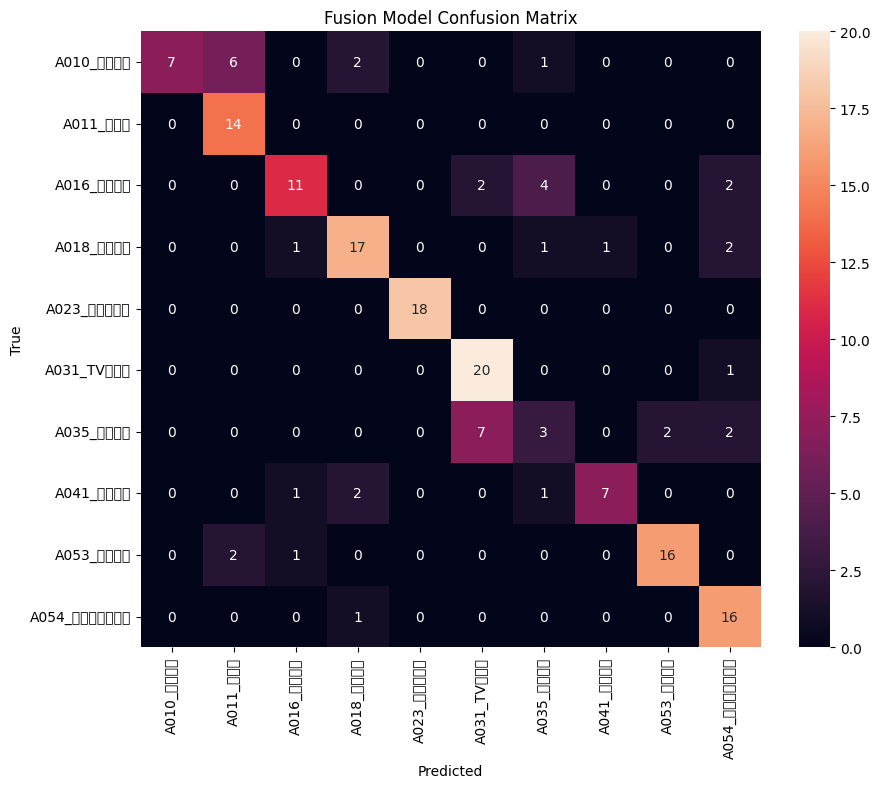

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Fusion Model Confusion Matrix")

plt.show()